Combining every concept I learned so far into this mini agent that mimics the future email assistant. 

the agent will:
- receive an email
- use a triage router
- if response, goes to tool calling loop to draft a reply
- interrupt before sending the email
- store a user preference after the human decision. 



In [56]:
from typing import TypedDict, Annotated
import operator
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.memory import InMemoryStore
from langgraph.types import interrupt, Command
from langchain_core.runnables import RunnableConfig

from langgraph.config import get_store

In [57]:
class AgentState(TypedDict):
    email: dict
    triage: str
    messages: Annotated[list[dict], operator.add]
    tool_calls: list[dict]
    sent: bool
    iterations: int

In [58]:
def draft_email(recipient: str, subject: str, body: str) -> str:
    return f"to: {recipient}\nsubject: {subject}\n\n{body}"

def schedule_meeting(title: str, data: str, time: str, attendees: list[str]) -> str:
    return f"Meeting '{title}' scheduled on {data} at {time} with {', '.join(attendees)}"

def check_calendar(date: str, time: str) -> str:
    return f"Calender is free on {date} at {time}"

def done() -> str:
    return "Done"

TOOLS = {
    "draft_email": draft_email,
    "schedule_meeting": schedule_meeting,
    "check_calendar": check_calendar,
    "done": done,
}  

In [59]:
class DummyLLM:
    def __init__(self, plan: list, max_iterations: int = 10):
        self.plan = plan
        self.step_index = 0
        self.max_iterations = max_iterations
    
    def __call__(self, state: AgentState) -> dict:
        if state['iterations'] >= self.max_iterations:
            return {
                "messages": [{"role": "assistant", "content": "Max iterations reached."}],
                "tool_calls": [],
            }
        
        if self.step_index >= len(self.plan):
            return {
                "messages": [{"role": "assistant", "content": "no more steps."}],
                "tool_calls": [],
            }

        step = self.plan[self.step_index]
        self.step_index += 1

        if step["type"] == "tool_call":
            if "calls" in step:
                calls = step["calls"]
            else:
                calls = [{"name": step["tool"], "arguments": step["args"]}]
            
            return {
                "messages" : [{"role": "assistant", "content": f"calling {len(calls)} tools"}],
                "tool_calls": calls,
                "iterations": state["iterations"] + 1,

            }
        else:
            return {
                "messages": [{"role": "assistant", "content": step["content"]}],
                "tool_calls": [],
                "iterations": state["iterations"] + 1,

            }

In [60]:
def triage_node(state: AgentState) -> dict:
    subject = state["email"]["subject"].lower()
    if "urgent" in subject or "meeting" in subject:
        return {"triage": "respond"}
    elif "newsletter" in subject or "promotion" in subject:
        return {"triage": "ignore"}
    else:
        return {"triage": "notify"}

In [61]:
def tool_node(state: AgentState) -> dict:
    if not state.get("tool_calls"):
        return {}
    
    tool_messages = []
    for call in state["tool_calls"]:
        name = call["name"]
        args = call["arguments"]
        func = TOOLS.get(name)

        if func is None:
            result = f"Error: unknow tool '{name}'"
        else:
            try:
                result = func(**args) if args else func()
            except TypeError:
                result = func(*args.values()) if args else func()
        tool_messages.append({"role": "tool", "content": str(result), "name": name})
    
    return {
        "messages": tool_messages,
        "tool_calls": [],
    }

        

In [62]:
def send_email_node(state: AgentState, config: RunnableConfig) -> dict:

    assistant_msgs = [m for m in state["messages"] if m["role"] == "assistant"]

    draft = assistant_msgs[-1]["content"] if assistant_msgs else "no draft"

    approval = interrupt({
        "draft": draft, 
        "question": "Approve sending this email?"
    })

    if approval.get("approve"):
        print("email sent")

        store = get_store()
        store.put(("users", "alice", "preferences"),"auto_approve", {"auto_approve": approval.get("remember", False)}
        )

        return {
            "sent": True,
            "messages": [{"role": "assistant", "content": "Email sent."}]
        }
    
    else: 
        return {
            "sent": False,
            "messages": [{"role": "assistant", "content": "Email not sent."}]
        }

In [63]:
def notify_node(state: AgentState) -> dict:
    return {"messages": [{"role": "assistant", "content": "user is notified"}]}

def route_after_triage(state: AgentState) -> str:
    if state["triage"] == "respond":
        return "llm"
    elif state["triage"] == "notify":
        return "notify"
    else:
        return END

def route_after_llm(state: AgentState) -> str:
    if state.get("tool_calls"):
        return "tool"
    else: 
        return "send_email"

def route_after_tool(state: AgentState) -> str:
    return "llm"

In [64]:
respond_plan = [
    {"type": "tool_call", "tool": "check_calendar", "args": {"date": "2025-01-15", "time": "10:00"}},
    {"type": "tool_call", "tool": "schedule_meeting", "args": {
        "title": "Project Sync",
        "date": "2025-01-15",
        "time": "10:00",
        "attendees": ["bob@example.com", "alice@example.com"]
    }},
    {"type": "tool_call", "tool": "draft_email", "args": {
        "recipient": "bob@example.com",
        "subject": "Re: Urgent Meeting",
        "body": "Hi Bob, the meeting is scheduled for Jan 15 at 10am. Best, Alice"
    }},
    {"type": "tool_call", "tool": "done", "args": {}},
    {"type": "final_answer", "content": "Meeting scheduled and email drafted."},
]


llm = DummyLLM(plan=respond_plan)

graph = StateGraph(AgentState)

graph.add_node("triage", triage_node)
graph.add_node("llm", llm)
graph.add_node("tool", tool_node)
graph.add_node("notify", notify_node)
graph.add_node("send_email", send_email_node)

graph.add_edge(START, "triage")
graph.add_conditional_edges(
    "triage",
    route_after_triage,
    {
        "llm": "llm",
        "notify": "notify",
        END: END
    }
)

graph.add_conditional_edges(
    "llm",
    route_after_llm,
    {
        "tool": "tool",
        "send_email": "send_email"
    }
)

graph.add_conditional_edges(
     "tool",
     route_after_tool,
     {
        "llm": "llm"
     }
)

graph.add_edge("send_email", END)

memory = MemorySaver()
store = InMemoryStore()

app = graph.compile(checkpointer=memory, store=store)

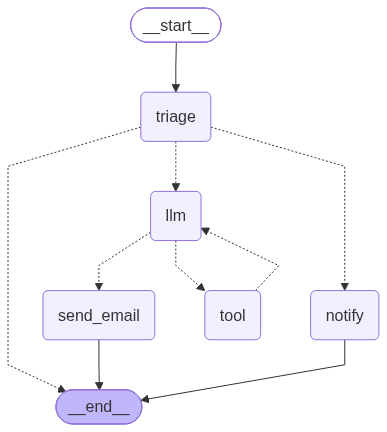

In [65]:
app

In [66]:
config = {"configurable": {"thread_id": "mini1"}}
initial_state = {
    "email": {"subject": "Urgent: Meeting", "sender": "bob@example.com", "body": "Need to discuss."},
    "triage": "",
    "messages": [],
    "tool_calls": [],
    "sent": False,
    "iterations": 0,
}

result = app.invoke(initial_state, config=config)

print("paused. Triage.", result["triage"])
print("Messages: ", result["messages"])
for m in result["messages"]:
    print(f" {m['role']}: {m['content']}")
print("interrupt:", result.get("__interrupt__"))



paused. Triage. respond
Messages:  [{'role': 'assistant', 'content': 'calling 1 tools'}, {'role': 'tool', 'content': 'Calender is free on 2025-01-15 at 10:00', 'name': 'check_calendar'}, {'role': 'assistant', 'content': 'calling 1 tools'}, {'role': 'tool', 'content': "Meeting 'Project Sync' scheduled on 2025-01-15 at 10:00 with bob@example.com, alice@example.com", 'name': 'schedule_meeting'}, {'role': 'assistant', 'content': 'calling 1 tools'}, {'role': 'tool', 'content': 'to: bob@example.com\nsubject: Re: Urgent Meeting\n\nHi Bob, the meeting is scheduled for Jan 15 at 10am. Best, Alice', 'name': 'draft_email'}, {'role': 'assistant', 'content': 'calling 1 tools'}, {'role': 'tool', 'content': 'Done', 'name': 'done'}, {'role': 'assistant', 'content': 'Meeting scheduled and email drafted.'}]
 assistant: calling 1 tools
 tool: Calender is free on 2025-01-15 at 10:00
 assistant: calling 1 tools
 tool: Meeting 'Project Sync' scheduled on 2025-01-15 at 10:00 with bob@example.com, alice@examp

In [67]:
app.get_state(config).interrupts[0].value

{'draft': 'Meeting scheduled and email drafted.',
 'question': 'Approve sending this email?'}

In [68]:
app.get_state(config).next

('send_email',)

In [69]:
command = Command(resume={"approve": True, "remember": True})

result = app.invoke(command, config=config)

for m in result["messages"]:
    print(f" {m['role']}: {m['content']}")
    

email sent
 assistant: calling 1 tools
 tool: Calender is free on 2025-01-15 at 10:00
 assistant: calling 1 tools
 tool: Meeting 'Project Sync' scheduled on 2025-01-15 at 10:00 with bob@example.com, alice@example.com
 assistant: calling 1 tools
 tool: to: bob@example.com
subject: Re: Urgent Meeting

Hi Bob, the meeting is scheduled for Jan 15 at 10am. Best, Alice
 assistant: calling 1 tools
 tool: Done
 assistant: Meeting scheduled and email drafted.
 assistant: Email sent.


In [70]:
config2 = {"configurable": {"thread_id": "mini2"}}
initial_state2 = {
    "email": {"subject": "Hello", "sender": "bob@example.com", "body": "How are you?"},
    "triage": "",
    "messages": [],
    "tool_calls": [],
    "sent": False,
    "iterations": 0,
}

result2 = app.invoke(initial_state2, config=config2)

print("Notify branch final message")
for m in result2["messages"]:
    print(f" {m['role']}: {m['content']}")



Notify branch final message
 assistant: user is notified


In [71]:
pref = store.get(("users", "alice", "preferences"), "auto_approve")
print("stored preferences: ", pref.value)

stored preferences:  {'auto_approve': True}


In [72]:
config3 = {"configurable": {"thread_id": "mini3"}}
initial_state3 = {
    "email": {"subject": "Newsletter: june updates", "sender": "bob@example.com", "body": "Grab this wonderful offer!"},
    "triage": "",
    "messages": [],
    "tool_calls": [],
    "sent": False,
    "iterations": 0,
}

result3 = app.invoke(initial_state3, config=config3)

print("Ignore branch final message")
print(result3)
for m in result3["messages"]:
    print(f" {m['role']}: {m['content']}")



Ignore branch final message
{'email': {'subject': 'Newsletter: june updates', 'sender': 'bob@example.com', 'body': 'Grab this wonderful offer!'}, 'triage': 'ignore', 'messages': [], 'tool_calls': [], 'sent': False, 'iterations': 0}
